# Put-Financed Floor (Collar Tranche) -- Math First, Then Liquidity, Then Engine

Builds directly on the guaranteed engine in `continuous_capital_recycling_sandbox.ipynb`.
Protocol (in order, gated): (1) the mathematics below, derived before touching data;
(2) the liquidity check in this notebook -- the engine only gets built if it passes;
(3) engine implementation reusing the exact same guaranteed-engine setup.

## 0. Why this does not contradict "puts kill performance"
That earlier finding was about BUYING puts -- redundant crash protection on a book that is
already short delta (the README's own point). This experiment SELLS OTM puts: harvesting
the crash-insurance premium that made buying them a losing trade. Mirror trade, same fact.

## 1. The collar tranche
Short n TSLL at S0, long n/100 calls strike K_c (premium C), SHORT n/100 puts strike
K_p < S0 (premium P_p collected), all same expiry T. Settlement P&L per the three regions:
```
S_T >= K_c:          n(S0 - K_c - C + P_p)         <- old floor, improved by +P_p
K_p <= S_T <= K_c:   n(S0 - S_T - C + P_p)         <- old profile, +P_p everywhere
S_T <= K_p:          n(S0 - K_p - C + P_p)          <- gain CAPPED (was unbounded)
```
**New exact reservation:**
```
L' = n * (C + K_c - S0 - P_p)      -- strictly smaller than L by the premium collected
```
Same alpha budget / smaller per-share reservation => MORE shares deployable per cycle.

## 2. The continuous floor survives (model-free)
A short American put's liability can exceed intrinsic mid-cycle (time value against us).
Two no-arbitrage bounds close the gap (no dividends assumed -- see caveats):
- American parity per strike:  P(K_p, t) <= C(K_p, t) - S_t + K_p
- Vertical spread bound:       C(K_p, t) - C(K_c, t) <= K_c - K_p

Chain them through the tranche mark-to-market:
```
tranche(t) = n(S0 - S_t) + n(C_c(t) - C) + n(P_p - P_put(t))
           >= n(S0 - S_t) + n C_c(t) - nC + nP_p - n(C_c(t) + K_c - S_t)
           =  -n(C + K_c - S0 - P_p)  =  -L'
```
Every S_t term cancels. The tranche is >= -L' at EVERY instant -- same guarantee class as
the call-only engine, with the improved reservation. The master equation
MaxDD <= (D+gamma)/(1+gamma) carries over unchanged.

## 3. The cost, honestly: gains cap at K_p
All of H1's crash alpha came from unbounded downside gains. BUT the gamma=8% ceiling
already settles cycles at +8% equity gain and re-enters at the new lower spot with new,
lower strikes -- deep crashes were already captured stepwise, not within one cycle. A put
~20-25% below entry may rarely bind before a checkpoint fires: collect P_p every cycle,
give up gains that were rarely realized in a single cycle anyway. Whether that holds is
an empirical question (the engine phase), not a math question.

## 4. Liquidity pass criteria (registered BEFORE running the check below)
The engine phase proceeds only if, on the TSLL chain:
- **Pairing**: on >= ~50% of days where a qualifying call anchor exists (same selection
  rules as the guaranteed engine), a SAME-EXPIRY put with K_p/S in [0.70, 0.90]
  (10-30% OTM) and px_volume > 0 also exists. Same expiry is required -- the algebra
  needs both legs settling at one checkpoint.
- **Richness**: median P_p/S of those matched puts >= ~1% of spot. If crash insurance on
  a 2x LETF isn't rich, the whole thesis is dead and we stop here.
- Failing either -> record the negative result and stop; no engine.

## Caveats
- Parity bound assumes no dividends/distributions on TSLL; LETF distributions would
  loosen it slightly -- flag if material.
- Short puts carry early-assignment in practice; the parity bound covers the *valuation*
  floor, and assignment realizes intrinsic (<= the bound), so the floor survives
  assignment too -- but real-world margin treatment is out of scope here, as everywhere
  else in this project.
- Same stale-quote issue as calls: put marks clamped to >= intrinsic (liability side:
  conservative direction is UP).


In [1]:
import sys, warnings
warnings.filterwarnings('ignore')
sys.path.insert(0, '../../scripts/eda')
sys.path.insert(0, '../../scripts/backtest')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

from data_loader import (load_tsll, load_tsll_calls, load_tsll_puts,
                          load_tsla_underlying, load_tsla_calls, load_tsla_puts)
from options_selection import select_contract

plt.style.use('seaborn-v0_8-whitegrid')

tsll_spot  = load_tsll().set_index('Date')['Close']
tsll_calls = load_tsll_calls()
tsll_puts  = load_tsll_puts()

tsll_cvol = tsll_calls[tsll_calls['px_volume'] > 0].copy()
tsll_cvol['dte']       = (pd.to_datetime(tsll_cvol['expiry']) - pd.to_datetime(tsll_cvol['date'])).dt.days
tsll_cvol['spot']      = tsll_cvol['date'].map(tsll_spot)
tsll_cvol['moneyness'] = tsll_cvol['strike'] / tsll_cvol['spot']

tsll_pvol = tsll_puts[tsll_puts['px_volume'] > 0].copy()
tsll_pvol = tsll_pvol[tsll_pvol['px_last'].notna() & (tsll_pvol['px_last'] > 0)]
tsll_pvol['dte']       = (pd.to_datetime(tsll_pvol['expiry']) - pd.to_datetime(tsll_pvol['date'])).dt.days
tsll_pvol['spot']      = tsll_pvol['date'].map(tsll_spot)
tsll_pvol['moneyness'] = tsll_pvol['strike'] / tsll_pvol['spot']
tsll_pvol['prem_pct']  = tsll_pvol['px_last'] / tsll_pvol['spot'] * 100

sim_dates = tsll_spot.index[tsll_spot.index >= tsll_cvol['date'].min()]

TARGET_DTE = 90
MAX_DTE    = 110
MIN_DTE_STRICT = 60
PUT_MONEY_LO, PUT_MONEY_HI = 0.70, 0.90   # 10-30% OTM puts

print(f'TSLL calls (vol>0): {len(tsll_cvol):,} rows  |  puts (vol>0): {len(tsll_pvol):,} rows')
print(f'Sim window: {sim_dates[0].date()} -> {sim_dates[-1].date()}  ({len(sim_dates)} days)')
print(f'Puts/day with volume: median {tsll_pvol.groupby("date").size().median():.0f}, '
      f'p10 {tsll_pvol.groupby("date").size().quantile(0.1):.0f}, '
      f'p90 {tsll_pvol.groupby("date").size().quantile(0.9):.0f}')


TSLL calls (vol>0): 46,867 rows  |  puts (vol>0): 55,978 rows
Sim window: 2022-08-12 -> 2026-06-10  (960 days)
Puts/day with volume: median 49, p10 14, p90 113


In [2]:
# --- Liquidity check 1: standalone availability + richness of OTM TSLL puts ------
q = tsll_pvol[(tsll_pvol['moneyness'] >= PUT_MONEY_LO) & (tsll_pvol['moneyness'] <= PUT_MONEY_HI)
              & (tsll_pvol['dte'] >= 45) & (tsll_pvol['dte'] <= MAX_DTE)]
days_with_q = q['date'].nunique()
print(f'Days with ANY 10-30% OTM put, 45-{MAX_DTE} DTE, volume>0: '
      f'{days_with_q}/{len(sim_dates)} ({days_with_q/len(sim_dates)*100:.0f}%)\n')

q = q.copy()
q['bucket'] = pd.cut(q['moneyness'], [0.70, 0.75, 0.80, 0.85, 0.90],
                     labels=['25-30% OTM', '20-25% OTM', '15-20% OTM', '10-15% OTM'])
rich = q.groupby('bucket', observed=True).agg(
    rows=('prem_pct', 'size'),
    median_prem_pct=('prem_pct', 'median'),
    p25=('prem_pct', lambda s: s.quantile(0.25)),
    p75=('prem_pct', lambda s: s.quantile(0.75)),
    median_volume=('px_volume', 'median'),
)
print('Premium richness by moneyness bucket (P/S, % of spot):')
print(rich.round(2).to_string())


Days with ANY 10-30% OTM put, 45-110 DTE, volume>0: 766/960 (80%)

Premium richness by moneyness bucket (P/S, % of spot):
            rows  median_prem_pct   p25    p75  median_volume
bucket                                                       
25-30% OTM   645             5.35  3.71   7.41           35.0
20-25% OTM   695             6.73  4.92   8.97           29.0
15-20% OTM   691             8.66  6.47  11.09           34.0
10-15% OTM   709            10.61  7.96  13.22           30.0


In [3]:
# --- Liquidity check 2: SAME-EXPIRY call+put pairing (the binding requirement) ----
# For each sim day, find the call anchor the guaranteed engine would pick (strict ATM
# 60-110 DTE, else relaxed 45-120 / 0.80-1.20), then ask: does a 10-30% OTM put with
# volume>0 exist at THAT expiry today?

def _select_tsll_relaxed(d):
    day = tsll_cvol[tsll_cvol['date'] == d]
    w = day[(day['dte'] >= 45) & (day['dte'] <= 120)
            & (day['moneyness'] >= 0.80) & (day['moneyness'] <= 1.20)]
    if w.empty:
        return None
    w = w.copy()
    w['ad'] = (w['moneyness'] - 1.0).abs()
    w['dd'] = (w['dte'] - TARGET_DTE).abs()
    return w.sort_values(['ad', 'dd']).iloc[0]

pair_rows = []
for d in sim_dates:
    row = select_contract(tsll_calls, tsll_spot, d, 'ATM', TARGET_DTE, max_dte=MAX_DTE)
    if row is not None and (row['expiry'] - d).days < MIN_DTE_STRICT:
        row = None
    if row is None:
        row = _select_tsll_relaxed(d)
    if row is None:
        continue
    exp = pd.Timestamp(row['expiry'])
    St  = float(tsll_spot.loc[d])
    pday = tsll_pvol[(tsll_pvol['date'] == d) & (tsll_pvol['expiry'] == exp)
                     & (tsll_pvol['moneyness'] >= PUT_MONEY_LO)
                     & (tsll_pvol['moneyness'] <= PUT_MONEY_HI)]
    if pday.empty:
        pair_rows.append(dict(date=d, call_exp=exp, paired=False,
                              put_prem_pct=np.nan, put_money=np.nan))
    else:
        best = pday.sort_values('moneyness').iloc[-1]   # closest to 10% OTM = richest
        pair_rows.append(dict(date=d, call_exp=exp, paired=True,
                              put_prem_pct=float(best['prem_pct']),
                              put_money=float(best['moneyness'])))

pairs = pd.DataFrame(pair_rows)
n_call_days = len(pairs)
n_paired    = int(pairs['paired'].sum())
med_prem    = float(pairs.loc[pairs['paired'], 'put_prem_pct'].median()) if n_paired else float('nan')

print(f'Days with a qualifying call anchor: {n_call_days}/{len(sim_dates)}')
print(f'...of which a SAME-EXPIRY 10-30% OTM put also trades: {n_paired} '
      f'({n_paired/max(n_call_days,1)*100:.0f}%)')
print(f'Median matched-put premium P_p/S: {med_prem:.2f}% of spot  |  '
      f'median matched-put moneyness: {pairs.loc[pairs["paired"], "put_money"].median():.2f}')

PASS_PAIRING  = n_paired / max(n_call_days, 1) >= 0.50
PASS_RICHNESS = med_prem >= 1.0
print(f'\nPRE-REGISTERED CRITERIA:  pairing >= 50%: {"PASS" if PASS_PAIRING else "FAIL"}  |  '
      f'median P_p/S >= 1%: {"PASS" if PASS_RICHNESS else "FAIL"}')
print('VERDICT:', 'proceed to engine' if (PASS_PAIRING and PASS_RICHNESS)
      else 'record negative result and stop -- no engine')


Days with a qualifying call anchor: 797/960
...of which a SAME-EXPIRY 10-30% OTM put also trades: 742 (93%)
Median matched-put premium P_p/S: 10.16% of spot  |  median matched-put moneyness: 0.86

PRE-REGISTERED CRITERIA:  pairing >= 50%: PASS  |  median P_p/S >= 1%: PASS
VERDICT: proceed to engine


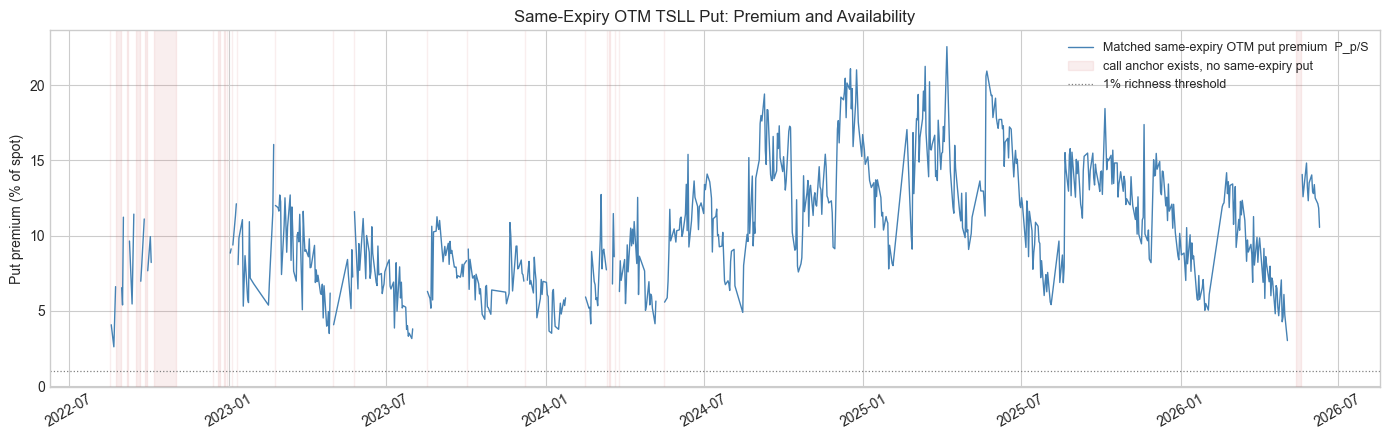

In [4]:
# --- Plot: matched-put premium over time + pairing availability -------------------
fig, ax = plt.subplots(figsize=(14, 4.5))
p = pairs.set_index('date')
ax.plot(p.index, p['put_prem_pct'], color='steelblue', lw=1.0,
        label='Matched same-expiry OTM put premium  P_p/S')
unpaired = ~p['paired']
ax.fill_between(p.index, 0, 1, where=unpaired, transform=ax.get_xaxis_transform(),
                color='indianred', alpha=0.10, label='call anchor exists, no same-expiry put')
ax.axhline(1.0, color='grey', lw=0.9, ls=':', label='1% richness threshold')
ax.set_ylabel('Put premium (% of spot)')
ax.set_title('Same-Expiry OTM TSLL Put: Premium and Availability')
ax.legend(fontsize=9, loc='upper right')
ax.tick_params(axis='x', rotation=30)
plt.tight_layout()
plt.savefig('../../observations/strategies/sandbox/put_financed_floor_liquidity.png',
            dpi=150, bbox_inches='tight')
plt.show()


## Engine phase (liquidity check passed: 93% pairing, median P_p/S = 10.2%)

A-priori rules, registered before running:
- **Put selection**: same expiry as the call leg, moneyness in [0.70, 0.90], closest to
  **0.80** (20% OTM) -- balances premium collected vs gain-cap room. Not the richest put.
- **Gate on NET floor cost**: `w' / S = (C + K_c - S0 - P_p)/S <= c_max = 15%`. Net is
  the true price of the floor; this is the mechanism that deploys more capital (same
  alpha budget / smaller per-share reservation).
- **Fallback**: no qualifying put -> call-only tranche with the gross reservation
  (identical to the guaranteed engine). Net cost < 0.5% of spot -> put quote treated as
  stale -> call-only fallback too.
- **Clamps**: every leg marks at max(quote, own intrinsic) -- value floor for the long
  call (no-arb, realizable by exercise), conservative liability floor for the short put
  (and what assignment realizes).
- Same (alpha, D, gamma, c_max) = (8%, 8.2%, 8%, 15%) as the guaranteed engine; same
  master equation bound = 15.0%. Same TSLL-only scope, settled accounting, cumulative
  cycle reservations, cycle-level ceiling.
- **Pre-registered prediction**: at high deployment the gamma=8% ceiling should usually
  fire BEFORE the ~20%-down gain cap binds. If results disagree, inspect that first.


In [5]:
# --- Engine setup: luts, params, leg mark-to-market, selectors --------------------
ALPHA   = 0.08
D_LIMIT = 0.082
GAMMA   = 0.08
C_MAX   = 0.15      # gate on NET floor cost for collar tranches (gross when call-only)

MIN_DTE_STRICT    = 60
MIN_TOPUP_DTE     = 20
MIN_NOTIONAL_FRAC = 0.01
PUT_TARGET_MONEY  = 0.80
MIN_NET_COST_FRAC = 0.005   # below this, put quote treated as stale -> call-only

tsll_call_lut = tsll_calls.set_index(['raw_id', 'date'])['px_last'].to_dict()
tsll_put_lut  = tsll_puts.set_index(['raw_id', 'date'])['px_last'].to_dict()


def _mtm_leg(leg, d, cap=None):
    """Mark one leg, confined to its no-arbitrage band.

    Floor: max(quote, own intrinsic) -- value floor for the long call (realizable by
    exercise), conservative liability floor for the short put (what assignment
    realizes).

    Ceiling (put legs only, passed by the engine): the chained parity bound
    P(t) <= C_c(t) + K_c - S_t, computed from the SAME tranche's freshly-marked call
    leg. A recorded put quote above this band was not a tradeable price (an arbitrageur
    would have sold it against the call), exactly as a call quote below intrinsic was
    not tradeable -- the thin-chain stale-quote artifact, mirrored on the liability
    side. Since K_c >= K_p, the ceiling provably never falls below put intrinsic, so
    the band is always well-defined. Past expiry: intrinsic."""
    S_now = float(tsll_spot.loc[d])
    intrinsic = max(S_now - leg['K'], 0.0) if leg['kind'] == 'C' else max(leg['K'] - S_now, 0.0)
    if d > leg['e']:
        return intrinsic
    lut = tsll_call_lut if leg['kind'] == 'C' else tsll_put_lut
    v = lut.get((leg['id'], d))
    px = max(float(v), intrinsic) if (v is not None and not pd.isna(v)) else max(leg['px'], intrinsic)
    if cap is not None:
        px = min(px, cap)
    return px


def _select_expiry_match_call(d, anchor_e, min_dte=MIN_TOPUP_DTE):
    day = tsll_cvol[tsll_cvol['date'] == d]
    w = day[(day['expiry'] <= anchor_e) & (day['dte'] >= min_dte)
            & (day['moneyness'] >= 0.80) & (day['moneyness'] <= 1.20)]
    if w.empty:
        return None
    w = w.copy()
    w['ed'] = (anchor_e - w['expiry']).dt.days
    w['ad'] = (w['moneyness'] - 1.0).abs()
    return w.sort_values(['ed', 'ad']).iloc[0]


def _select_call(d, anchor_e):
    """Same call selection as the guaranteed engine: strict ATM 60-110 anchor, relaxed
    fallback; expiry-matched top-up when a cycle is open."""
    if anchor_e is None:
        row = select_contract(tsll_calls, tsll_spot, d, 'ATM', TARGET_DTE, max_dte=MAX_DTE)
        if row is not None and (row['expiry'] - d).days >= MIN_DTE_STRICT:
            return row, 'anchor'
        rr = _select_tsll_relaxed(d)
        if rr is not None:
            return rr, 'anchor-rlx'
        return None, None
    rr = _select_expiry_match_call(d, anchor_e)
    if rr is not None:
        return rr, 'top-up'
    return None, None


def _select_put(d, exp):
    """Same-expiry put, moneyness in [0.70, 0.90], closest to PUT_TARGET_MONEY."""
    pday = tsll_pvol[(tsll_pvol['date'] == d) & (tsll_pvol['expiry'] == exp)
                     & (tsll_pvol['moneyness'] >= PUT_MONEY_LO)
                     & (tsll_pvol['moneyness'] <= PUT_MONEY_HI)]
    if pday.empty:
        return None
    pday = pday.copy()
    pday['td'] = (pday['moneyness'] - PUT_TARGET_MONEY).abs()
    return pday.sort_values('td').iloc[0]


print('Engine helpers defined.')

Engine helpers defined.


In [6]:
# --- Collar engine (use_puts toggles the put leg; False == guaranteed engine) -----

def simulate_collar(sim_dates, alpha=ALPHA, dd_limit=D_LIMIT, gamma=GAMMA,
                     c_max=C_MAX, use_puts=True, notional=1.0):
    """Settled accounting, cumulative cycle reservations, cycle ceiling, synchronized
    expiries -- identical scaffolding to simulate_guaranteed. Each tranche holds a long
    call and optionally a short same-expiry put:
        w' = C + K_c - S0 - P_p   (per-share exact reservation; gross if no put)
        continuous floor at -n*w' via American parity + vertical-spread bounds.
    Marks: call leg first (intrinsic floor), then the put leg confined to its no-arb
    band [put intrinsic, C_c(t) + K_c - S_t] using the fresh call mark.
    """
    equity        = pd.Series(index=sim_dates, dtype=float)
    deployed_frac = pd.Series(index=sim_dates, dtype=float)
    floor_series  = pd.Series(index=sim_dates, dtype=float)

    total_spnl = total_opnl = total_cpnl = 0.0
    Sp              = float(tsll_spot.loc[sim_dates[0]])
    undeployed_cash = notional
    total_n_sh      = 0.0
    open_positions  = []
    E0              = notional
    ath_star        = notional
    anchor_e        = None
    cycle_reserved  = 0.0
    log             = []
    checkpoints     = []

    for d in sim_dates:
        St = float(tsll_spot.loc[d])

        total_spnl += total_n_sh * (Sp - St)
        total_cpnl += undeployed_cash * R_RF_D
        Sp = St

        for pos in open_positions:
            call_leg = pos['legs'][0]                      # legs[0] is always the call
            px_c = _mtm_leg(call_leg, d)
            total_opnl += call_leg['side'] * pos['n_sh'] * (px_c - call_leg['px'])
            call_leg['px'] = px_c
            if len(pos['legs']) > 1:
                put_leg = pos['legs'][1]
                px_p = _mtm_leg(put_leg, d, cap=px_c + call_leg['K'] - St)
                total_opnl += put_leg['side'] * pos['n_sh'] * (px_p - put_leg['px'])
                put_leg['px'] = px_p

        equity_now = notional + total_spnl + total_opnl + total_cpnl

        ceiling_hit = bool(open_positions) and equity_now >= E0 * (1.0 + gamma)

        still_open = []
        for pos in open_positions:
            if ceiling_hit or d > pos['e']:
                total_n_sh      -= pos['n_sh']
                undeployed_cash += pos['capital_at_open']
                log.append({'start': pos['start'], 'end': d, 'n_sh': pos['n_sh'],
                            'reserved': pos['reserved'], 'tier': pos['tier'],
                            'net_cost_pct': pos['net_cost_pct'],
                            'has_put': pos['has_put'], 'Kp_money': pos['Kp_money'],
                            'ceiling': ceiling_hit, 'open_at_end': False})
            else:
                still_open.append(pos)
        open_positions = still_open

        if not open_positions:
            if anchor_e is not None or ceiling_hit:
                checkpoints.append({'date': d, 'E0': equity_now,
                                    'type': 'ceiling' if ceiling_hit else 'expiry'})
            E0             = equity_now
            ath_star       = max(ath_star, equity_now)
            anchor_e       = None
            cycle_reserved = 0.0

        budget = min(alpha * E0, E0 - (1.0 - dd_limit) * ath_star) - cycle_reserved
        if budget > 0 and undeployed_cash > 1e-9:
            row, kind = _select_call(d, anchor_e)
            if row is not None:
                C_, K_ = float(row['px_last']), float(row['strike'])
                exp    = pd.Timestamp(row['expiry'])

                put = _select_put(d, exp) if use_puts else None
                P_p = float(put['px_last']) if put is not None else 0.0
                K_p = float(put['strike'])  if put is not None else float('nan')

                w = C_ + K_ - St - P_p
                if put is not None and w < MIN_NET_COST_FRAC * St:
                    put, P_p, K_p = None, 0.0, float('nan')   # stale put quote -> call-only
                    w = C_ + K_ - St
                w = max(w, 1e-9)

                if w / St <= c_max:
                    n_sh = min(budget / w, undeployed_cash / St)
                    if n_sh > 0 and n_sh * St >= MIN_NOTIONAL_FRAC * E0:
                        legs = [{'side': +1, 'kind': 'C', 'id': row['raw_id'],
                                 'K': K_, 'e': exp, 'px': C_}]
                        if put is not None:
                            legs.append({'side': -1, 'kind': 'P', 'id': put['raw_id'],
                                         'K': K_p, 'e': exp, 'px': P_p})
                        open_positions.append({
                            'legs': legs, 'e': exp, 'n_sh': n_sh,
                            'reserved': n_sh * w, 'capital_at_open': n_sh * St,
                            'start': d, 'tier': f'TSLL {kind}',
                            'net_cost_pct': w / St * 100,
                            'has_put': put is not None,
                            'Kp_money': (K_p / St) if put is not None else float('nan'),
                        })
                        total_n_sh      += n_sh
                        undeployed_cash -= n_sh * St
                        cycle_reserved  += n_sh * w
                        if anchor_e is None:
                            anchor_e = exp

        equity.loc[d]        = equity_now
        deployed_frac.loc[d] = (total_n_sh * St) / equity_now if equity_now > 0 else 0.0
        floor_series.loc[d]  = max((1.0 - alpha) * E0, (1.0 - dd_limit) * ath_star)

    for pos in open_positions:
        log.append({'start': pos['start'], 'end': sim_dates[-1], 'n_sh': pos['n_sh'],
                    'reserved': pos['reserved'], 'tier': pos['tier'],
                    'net_cost_pct': pos['net_cost_pct'],
                    'has_put': pos['has_put'], 'Kp_money': pos['Kp_money'],
                    'ceiling': False, 'open_at_end': True})

    return (equity, deployed_frac, pd.DataFrame(log),
            pd.DataFrame({'floor': floor_series}), pd.DataFrame(checkpoints))

R_RF   = 0.05
R_RF_D = R_RF / 252
print('simulate_collar() defined.')

simulate_collar() defined.


In [7]:
# --- Run: collar vs call-only (in-notebook consistency baseline) -------------------
bound = (D_LIMIT + GAMMA) / (1.0 + GAMMA)

print(f'Collar engine (use_puts=True, alpha={ALPHA:.0%}, D={D_LIMIT:.1%}, gamma={GAMMA:.0%}, '
      f'c_max={C_MAX:.0%} net)...')
eq_col, dep_col, log_col, diag_col, cp_col = simulate_collar(sim_dates, use_puts=True)
n_put = int(log_col['has_put'].sum())
print(f'Done. {len(log_col)} tranches ({n_put} with put leg), {len(cp_col)} checkpoints '
      f'({int((cp_col["type"] == "ceiling").sum()) if not cp_col.empty else 0} ceiling).')

print('Call-only baseline (use_puts=False) -- should track the guaranteed engine...')
eq_co, dep_co, log_co, diag_co, cp_co = simulate_collar(sim_dates, use_puts=False)
print(f'Done. {len(log_co)} tranches, {len(cp_co)} checkpoints.')

def quick_stats(eq, label):
    ret    = eq.pct_change().dropna()
    n_yrs  = (eq.index[-1] - eq.index[0]).days / 365.25
    cagr   = eq.iloc[-1] ** (1/n_yrs) - 1
    sharpe = ret.mean() / ret.std() * 252**0.5
    maxdd  = float((eq / eq.cummax() - 1).min())
    return dict(Strategy=label, CAGR=cagr, Sharpe=sharpe, MaxDD=maxdd,
                Calmar=cagr / abs(maxdd) if maxdd != 0 else float('nan'))

rows = [
    quick_stats(eq_col, f'Collar (put-financed floor, {n_put}/{len(log_col)} tranches w/ put)'),
    quick_stats(eq_co,  'Call-only (this notebook, consistency baseline)'),
]
cmp_df = pd.DataFrame(rows).set_index('Strategy')
cmp_df.loc['Guaranteed engine (other notebook, reference)'] = [0.1400, 0.841, -0.1129, 1.240]
cmp_df.loc['Prior best (static, reference)']                = [0.1942, 0.928, -0.1970, 0.986]

fmt2 = {'CAGR':'{:+.2%}','Sharpe':'{:.3f}','MaxDD':'{:.2%}','Calmar':'{:.3f}'}
display(cmp_df.style.format(fmt2).set_caption(
    f'Put-financed floor  |  pre-registered MaxDD bound = {bound:.1%}'))


Collar engine (use_puts=True, alpha=8%, D=8.2%, gamma=8%, c_max=15% net)...
Done. 20 tranches (18 with put leg), 19 checkpoints (6 ceiling).
Call-only baseline (use_puts=False) -- should track the guaranteed engine...


Done. 20 tranches, 19 checkpoints.


,CAGR,Sharpe,MaxDD,Calmar
Strategy,,,,
"Collar (put-financed floor, 18/20 tranches w/ put)",+15.69%,0.899,-12.29%,1.277
"Call-only (this notebook, consistency baseline)",+14.00%,0.841,-11.29%,1.240
"Guaranteed engine (other notebook, reference)",+14.00%,0.841,-11.29%,1.240
"Prior best (static, reference)",+19.42%,0.928,-19.70%,0.986


In [8]:
# --- DIAGNOSTIC (post-run): verify guarantees + collar-specific checks -------------
for label, eq_v, diag_v, log_v in [('collar', eq_col, diag_col, log_col),
                                    ('call-only', eq_co, diag_co, log_co)]:
    breach   = eq_v < diag_v['floor'] - 1e-9
    n_breach = int(breach.sum())
    maxdd    = float((eq_v / eq_v.cummax() - 1).min())
    ok = 'WITHIN BOUND' if abs(maxdd) <= bound + 1e-9 else 'BOUND EXCEEDED -- investigate'
    print(f'=== {label} ===')
    print(f'Floor check: {n_breach} violations on {len(eq_v)} days')
    if n_breach:
        gaps = (eq_v - diag_v['floor'])[breach]
        rets = tsll_spot.pct_change().reindex(gaps.index)
        for dt, g in gaps.items():
            print(f'  {dt.date()}  gap={g:+.5f} ({g / eq_v.loc[dt] * 100:+.2f}% of equity)  '
                  f'TSLL day move: {rets.loc[dt] * 100:+.1f}%')
    print(f'MaxDD check: realized {maxdd:.2%} vs bound -{bound:.1%} -> {ok}  '
          f'({abs(maxdd)/bound:.0%} of envelope)')
    if 'net_cost_pct' in log_v.columns and len(log_v):
        print(f'Median tranche net floor cost: {log_v["net_cost_pct"].median():.2f}% of spot')
    print()

print(f'Mean deployed -- collar: {dep_col.mean()*100:.1f}%   call-only: {dep_co.mean()*100:.1f}%')
n_ceil = int((cp_col['type'] == 'ceiling').sum()) if not cp_col.empty else 0
print(f'Collar checkpoints: {len(cp_col)} total, {n_ceil} ceiling -- prediction was that '
      f'ceilings fire before the ~20%-down gain cap binds; inspect per-tranche log if not.')

=== collar ===
Floor check: 0 violations on 960 days
MaxDD check: realized -12.29% vs bound -15.0% -> WITHIN BOUND  (82% of envelope)
Median tranche net floor cost: 9.24% of spot

=== call-only ===
Floor check: 0 violations on 960 days
MaxDD check: realized -11.29% vs bound -15.0% -> WITHIN BOUND  (75% of envelope)
Median tranche net floor cost: 13.73% of spot

Mean deployed -- collar: 32.2%   call-only: 19.2%
Collar checkpoints: 19 total, 6 ceiling -- prediction was that ceilings fire before the ~20%-down gain cap binds; inspect per-tranche log if not.
